In [ ]:
import gc
gc.collect()
import numpy as np
import pandas as pd
import os
import sys
from omegaconf import OmegaConf
import matplotlib.pyplot as plt
import shap

# Adjust the path to point to external/AlphaPEM
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.sampling.sampler import get_polarisation_curve_samples, build_fixed_parameters
from src.analysis.feature_effects import FeatureEffects
from src.validity.validity_criteria import validate_polarization_curves
from src.utils.FE_io import load_cv_results, save_FE_results, load_FE_results
from src.utils.FE_plotting import plot_shap_bar, plot_sobol_index_convergence, plot_sobol_ranking, plot_top_k_rankings_across_regions
from src.utils.auxiliar_func_FE import select_top_features

## **Load the model**

In [27]:
model_xgboost, best_params_xgboost, metrics_xgboost = load_cv_results(
    save_dir='../results/sm/xgboost',
    run_name='xgb_nconfig_50000_no_neg_with_outerCV'
)

[INFO] Loaded model from ../results/sm/xgboost\xgb_nconfig_50000_no_neg_with_outerCV_final_model.pkl
[INFO] Loaded hyperparameters from ../results/sm/xgboost\xgb_nconfig_50000_no_neg_with_outerCV_best_params.json
[INFO] Loaded metrics from ../results/sm/xgboost\xgb_nconfig_50000_no_neg_with_outerCV_metrics.json


## **Load valid data**

In [28]:
data = pd.read_pickle(r"../sampling_test/validated_final_df_57344_imputed.pkl")
data = data[data['classification'] == 'valid']
parameter_ranges = OmegaConf.load('../param_config.yaml')

ifc_columns = [col for col in data.columns if col.startswith("ifc_")]
ucell_columns = [col for col in data.columns if col.startswith("Ucell_")]

In [29]:
stats = {
    "mean": data['ifc_30'].mean(),
    "median": data['ifc_30'].median(),
    "std": data['ifc_30'].std(),
    "percentile_5": data['ifc_30'].quantile(0.05),
    "percentile_99": data['ifc_30'].quantile(0.99)
}
print(stats)

{'mean': np.float64(3.0008128206957645), 'median': np.float64(3.0008148845932023), 'std': np.float64(0.0004897074980733162), 'percentile_5': np.float64(3.0008051534396203), 'percentile_99': np.float64(3.0008255649503406)}


In [30]:
stats = {
    "mean": data['ifc_30'].mean(),
    "median": data['ifc_30'].median(),
    "std": data['ifc_30'].std(),
    "percentile_5": data['ifc_30'].quantile(0.05),
    "percentile_99": data['ifc_30'].quantile(0.99)
}
print(stats)

{'mean': np.float64(3.0008128206957645), 'median': np.float64(3.0008148845932023), 'std': np.float64(0.0004897074980733162), 'percentile_5': np.float64(3.0008051534396203), 'percentile_99': np.float64(3.0008255649503406)}


In [31]:
criteria = {
    "start_in_range": True,
    "approx_monotonic": True,
    "low_ifc_positive_voltage": True
}

validated_df = validate_polarization_curves(
    data,
    apply_criteria=criteria,
    filter_invalid=True,
    voltage_range=(0, 1.23),
    approx_monotonic_threshold=0.05
)

print(len(validated_df))  # Should be 54754

54754


In [32]:
columns = list(parameter_ranges.keys())
columns.extend(['Ucell', 'ifc', 'SHA256'])

df_exploded = data[columns].explode(['ifc', 'Ucell'], ignore_index=True)
df_exploded.shape

(1745672, 16)

In [33]:
df_exploded = df_exploded[df_exploded.Ucell>=0]
df_exploded.shape

(1708686, 16)

## **Activation**

In [9]:
# Optionally, load the results
#FE_act_shap_results, FE_act_sobol_ = load_FE_results(region_name = "activation", 
                #save_dir = "../results/sm/xgboost", 
                #tag="17072025")

In [35]:
FE_act = FeatureEffects(model=model_xgboost, parameter_ranges =parameter_ranges, region="activation")

In [11]:
RAW_shap_values_act, FE_act_shap_results = FE_act.shap(df= df_exploded, target_col='Ucell', sample_frac=1.0, verbose=True)

[WARN] Found non-numeric columns: ['ifc']
[INFO] Converted column 'ifc' to numeric.
[INFO] Using full dataset (225101 rows) for SHAP.
[INFO] Creating SHAP TreeExplainer...
[INFO] Computing SHAP values...
[INFO] columns ['Tfc', 'Pa_des', 'Sc', 'Phi_c_des', 'epsilon_gdl', 'tau', 'epsilon_mc', 'epsilon_c', 'e', 'Re', 'i0_c_ref', 'kappa_co', 'kappa_c', 'ifc']
[INFO] Aggregating mean absolute SHAP values per feature...


In [12]:
FE_act_shap_results

,feature,mean_abs_shap
13,ifc,0.240813
10,i0_c_ref,0.043041
12,kappa_c,0.029081
0,Tfc,0.025537
1,Pa_des,0.022604
9,Re,0.010377
5,tau,0.009832
11,kappa_co,0.008020
6,epsilon_mc,0.007924
2,Sc,0.006282


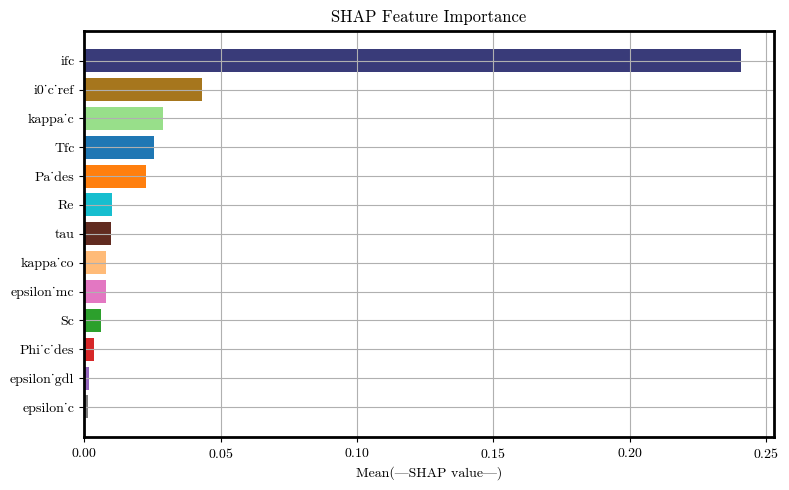

In [13]:
plot_shap_bar(FE_act_shap_results)

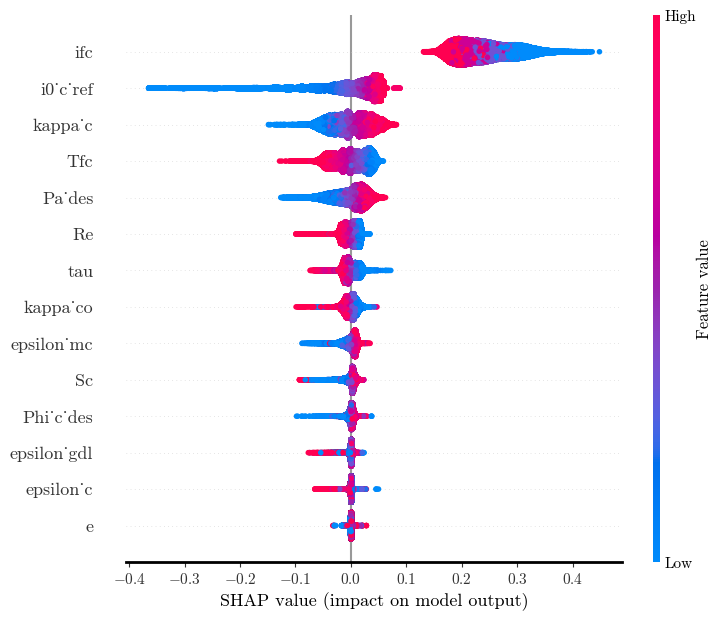

In [15]:
shap.plots.beeswarm(RAW_shap_values_act, max_display=14)

In [36]:
N_list = list(range(2, 8192, 4)) #[256, 512, 1024, 2048, 4096, 8192]  
FE_act_sobol_ = FE_act.sobol(N_list= N_list, calculate_second_order=True,verbose=False)

d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))
d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\scipy\stats\_qmc.py:993: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)
d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or

KeyboardInterrupt: 

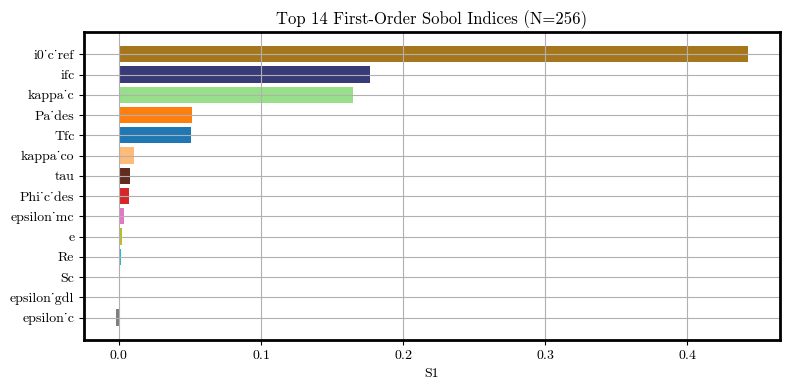

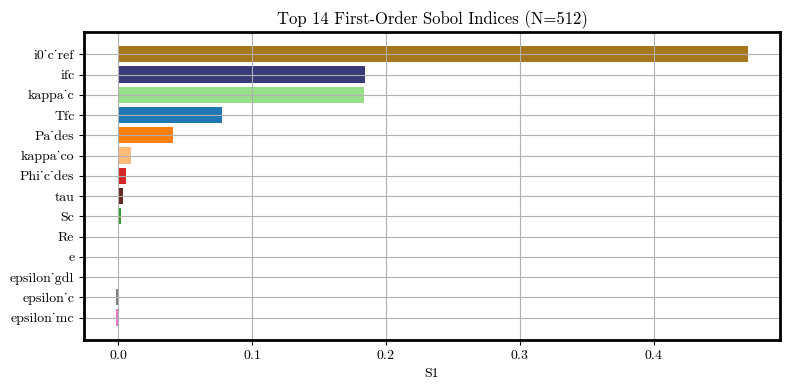

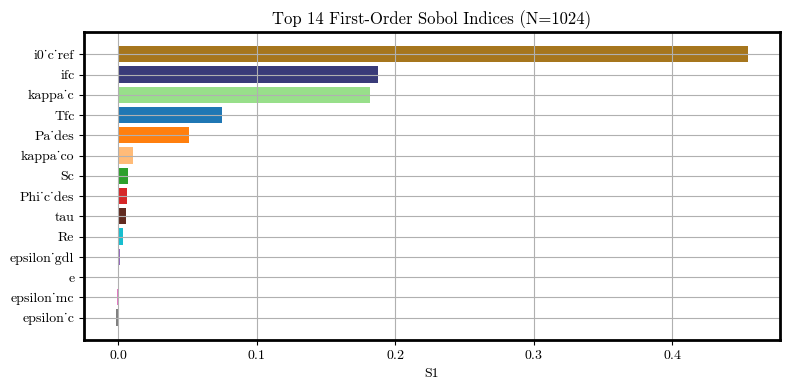

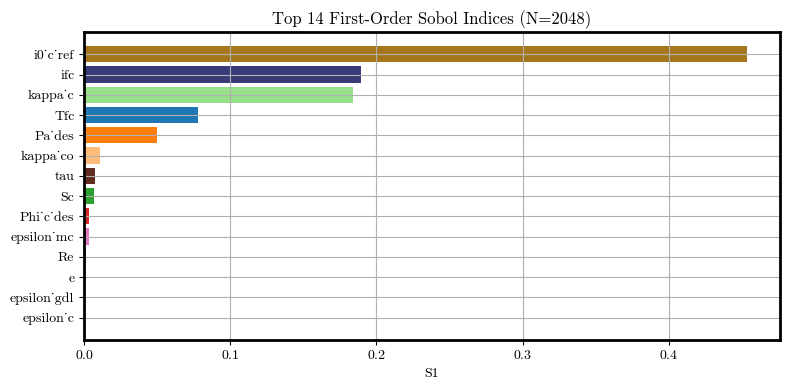

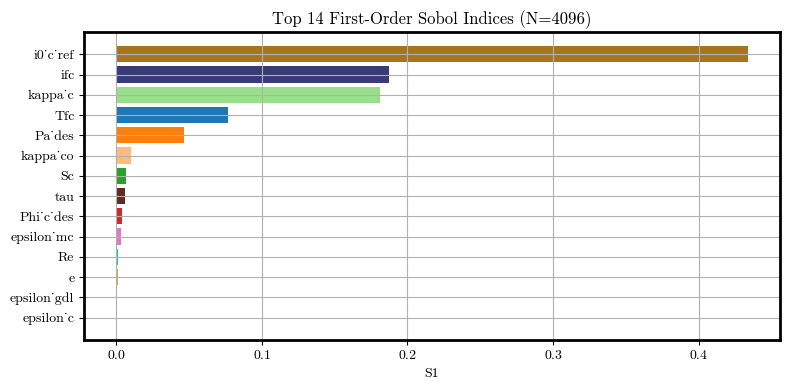

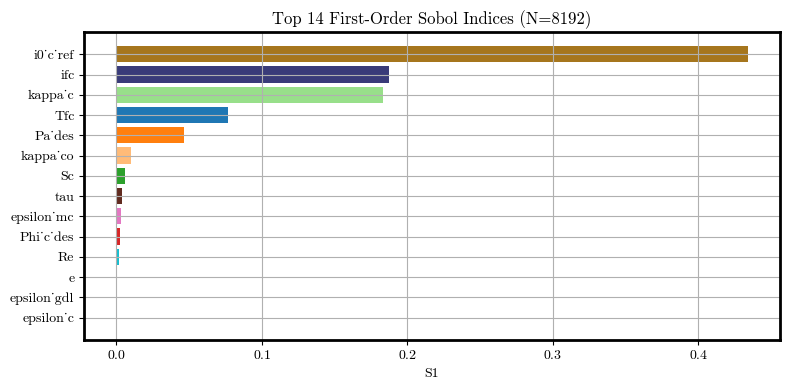

In [18]:
plot_sobol_ranking(FE_act_sobol_, top_n=14)

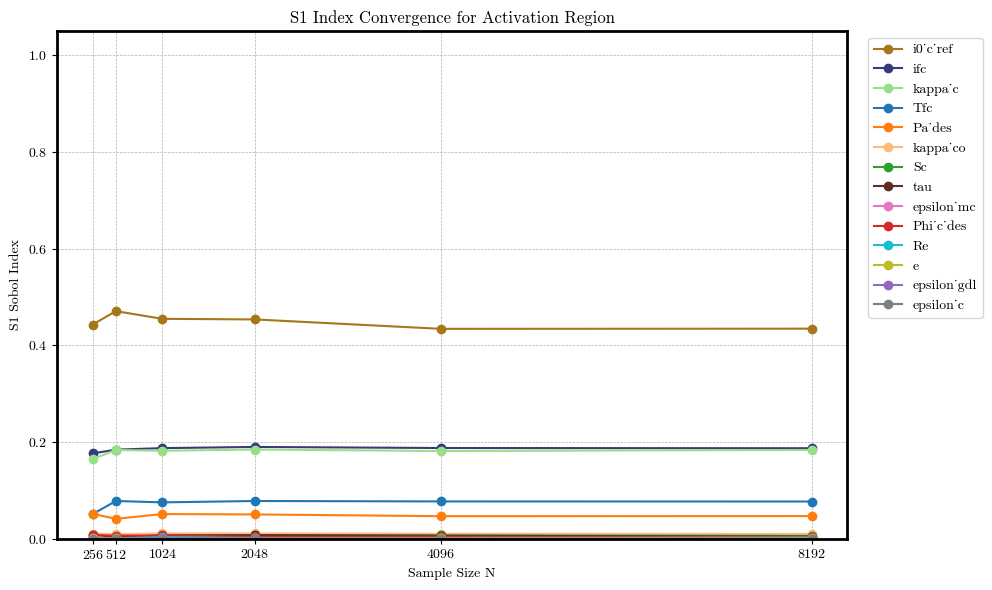

In [19]:
plot_sobol_index_convergence(FE_act_sobol_, top_k=14, index_type="S1", log_x=False, region = "Activation")

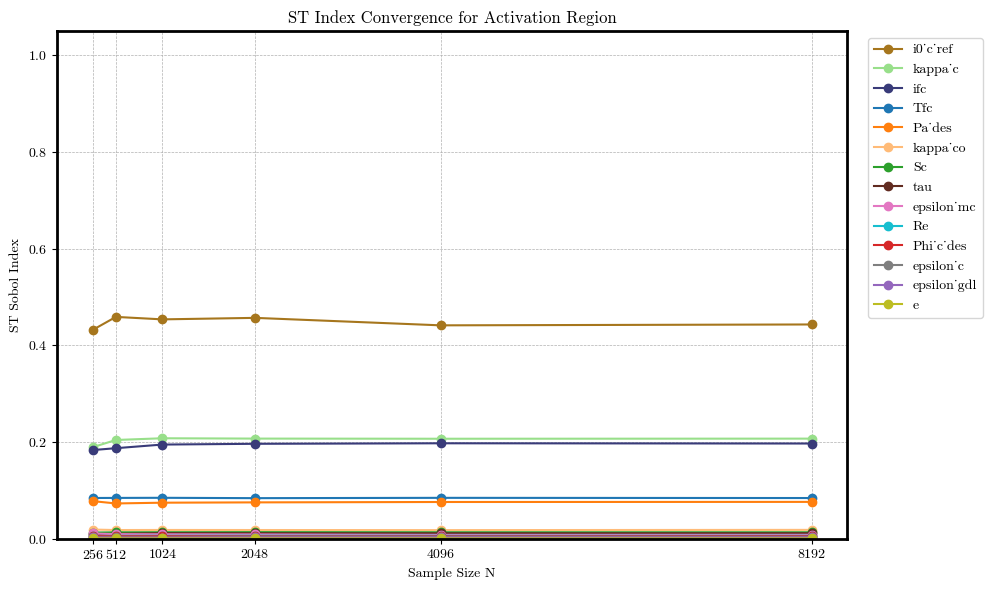

In [14]:
plot_sobol_index_convergence(FE_act_sobol_, top_k=14, index_type="ST", log_x=False, region = "Activation")

In [21]:
save_FE_results(
    region_name="activation",
    raw_shap =RAW_shap_values_act,
    shap_df =FE_act_shap_results,
    sobol_results=FE_act_sobol_,
    save_dir="../results/sm/xgboost",
    tag="28072025"
)

[INFO] Saved SHAP ranking to ../results/sm/xgboost\xgb_activation_28072025_shap.csv
[INFO] Saved raw SHAP Explanation to ../results/sm/xgboost\xgb_activation_28072025_raw_shap.pkl
[INFO] Saved all Sobol results to ../results/sm/xgboost\xgb_activation_28072025_sobol_results.pkl


## **Ohmic**

In [ ]:
# Optionally, load the results
#FE_ohm_shap_results, FE_ohm_sobol_ = load_FE_results(region_name = "ohmic", 
#                save_dir = "../results/sm/xgboost", 
#                tag="17072025")

[INFO] Loaded SHAP ranking from ../results/sm/xgboost\xgb_ohmic_17072025_shap.csv
[WARN] Sobol results not found: ../results/sm/xgboost\xgb_ohmic_17072025_sobol_results.pkl


In [9]:
FE_ohm = FeatureEffects(model=model_xgboost, parameter_ranges =parameter_ranges, region="ohmic")

In [10]:
FE_ohm.parameter_ranges

{'Tfc': [333, 363], 'Pa_des': [130000.0, 300000.0], 'Sc': [1.1, 3.0], 'Phi_c_des': [0.1, 0.7], 'epsilon_gdl': [0.55, 0.8], 'tau': [1.0, 4.0], 'epsilon_mc': [0.15, 0.4], 'epsilon_c': [0.15, 0.3], 'e': [3, 4, 5], 'Re': [5e-07, 5e-06], 'i0_c_ref': [0.001, 80], 'kappa_co': [15, 40], 'kappa_c': [0, 2.5], 'ifc': [0.4, 1.6]}

In [11]:
RAW_shap_values_ohm, FE_ohm_shap_results = FE_ohm.shap(df= df_exploded, target_col='Ucell', sample_frac=1.0, verbose=True)

[WARN] Found non-numeric columns: ['ifc']
[INFO] Converted column 'ifc' to numeric.
[INFO] Using full dataset (666062 rows) for SHAP.
[INFO] Creating SHAP TreeExplainer...
[INFO] Computing SHAP values...
[INFO] columns ['Tfc', 'Pa_des', 'Sc', 'Phi_c_des', 'epsilon_gdl', 'tau', 'epsilon_mc', 'epsilon_c', 'e', 'Re', 'i0_c_ref', 'kappa_co', 'kappa_c', 'ifc']
[INFO] Aggregating mean absolute SHAP values per feature...


In [12]:
FE_ohm_shap_results

,feature,mean_abs_shap
13,ifc,0.067320
10,i0_c_ref,0.042765
1,Pa_des,0.030510
0,Tfc,0.029974
12,kappa_c,0.026851
9,Re,0.014544
5,tau,0.013732
6,epsilon_mc,0.010955
3,Phi_c_des,0.006994
2,Sc,0.005556


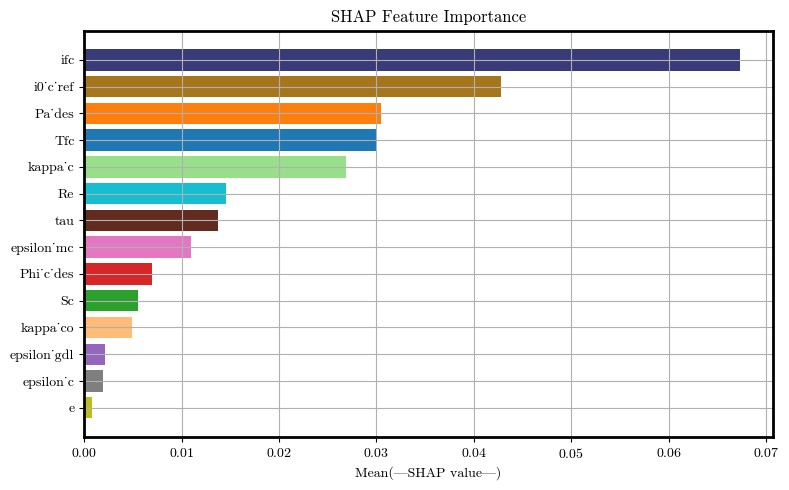

In [13]:
plot_shap_bar(FE_ohm_shap_results, top_n=14)

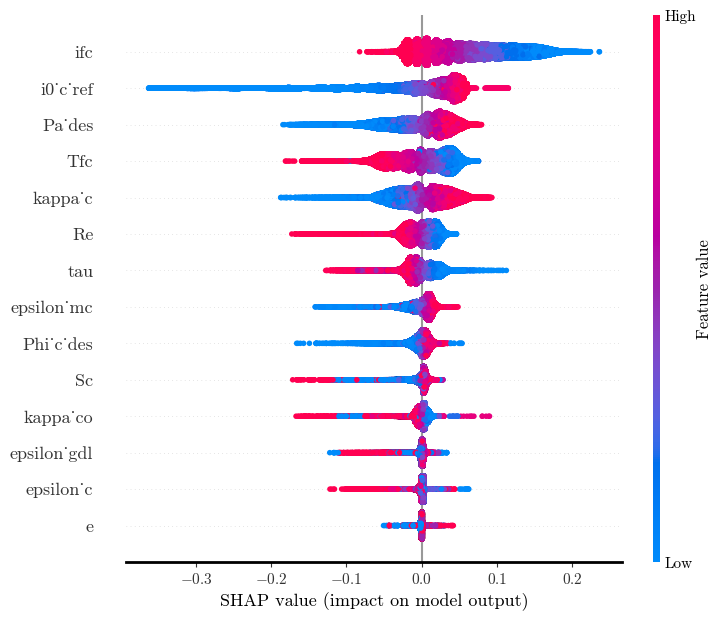

In [14]:
shap.plots.beeswarm(RAW_shap_values_ohm, max_display=14)

In [15]:
N_list = [256, 512, 1024, 2048, 4096, 8192]  
FE_ohm_sobol_ = FE_ohm.sobol(N_list= N_list, calculate_second_order=True,verbose=True)

d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 256 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.8916
[INFO] Sum S2 (unique pairs) = 0.9037
[INFO] Sum S1 + S2 = 1.7952 (should be ≈ 1)
[INFO] Sum ST = 1.0562 (may be > 1 due to overlaps)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 512 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9610
[INFO] Sum S2 (unique pairs) = 0.3143
[INFO] Sum S1 + S2 = 1.2753 (should be ≈ 1)
[INFO] Sum ST = 1.0788 (may be > 1 due to overlaps)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


...

[INFO] Analyzing 2048 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9559
[INFO] Sum S2 (unique pairs) = 0.0827
[INFO] Sum S1 + S2 = 1.0386 (should be ≈ 1)
[INFO] Sum ST = 1.0840 (may be > 1 due to overlaps)


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 4096 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9431
[INFO] Sum S2 (unique pairs) = 0.0545
[INFO] Sum S1 + S2 = 0.9977 (should be ≈ 1)
[INFO] Sum ST = 1.0798 (may be > 1 due to overlaps)


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 8192 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9464
[INFO] Sum S2 (unique pairs) = 0.0675
[INFO] Sum S1 + S2 = 1.0139 (should be ≈ 1)
[INFO] Sum ST = 1.0799 (may be > 1 due to overlaps)


In [38]:
FE_ohm_sobol_[8192]['sobol_df']

,feature,S1,S1_CI,ST,ST_CI,S2_total,S2_CI
0,i0_c_ref,0.304579,"(0.285, 0.324)",0.314488,"(0.3, 0.329)",0.005508,"(-0.089, 0.1)"
1,ifc,0.276962,"(0.262, 0.292)",0.288082,"(0.277, 0.299)",0.000000,"(0.0, 0.0)"
2,Pa_des,0.106903,"(0.096, 0.118)",0.131925,"(0.126, 0.138)",0.047934,"(-0.158, 0.254)"
3,kappa_c,0.095754,"(0.085, 0.107)",0.119098,"(0.114, 0.124)",0.000678,"(-0.016, 0.017)"
4,Tfc,0.104992,"(0.095, 0.115)",0.116435,"(0.112, 0.121)",0.010159,"(-0.193, 0.213)"
5,tau,0.018316,"(0.014, 0.023)",0.028615,"(0.027, 0.03)",0.008798,"(-0.049, 0.066)"
6,Re,0.015115,"(0.01, 0.02)",0.023092,"(0.022, 0.024)",0.002576,"(-0.025, 0.031)"
7,epsilon_mc,0.011614,"(0.007, 0.016)",0.019311,"(0.018, 0.02)",-0.003862,"(-0.047, 0.039)"
8,Phi_c_des,0.008322,"(0.005, 0.012)",0.015139,"(0.014, 0.016)",-0.005070,"(-0.058, 0.048)"
9,Sc,0.001669,"(-0.001, 0.004)",0.009644,"(0.009, 0.01)",-0.005823,"(-0.047, 0.036)"


In [16]:
FE_ohm_sobol_

{256: {'sobol_df':         feature        S1            S1_CI        ST           ST_CI  \
  0      i0_c_ref  0.312283    (0.17, 0.455)  0.327114  (0.258, 0.396)   
  1           ifc  0.246570   (0.158, 0.335)  0.260329   (0.211, 0.31)   
  2        Pa_des  0.112109   (0.047, 0.177)  0.131299  (0.102, 0.161)   
  3           Tfc  0.081131   (0.018, 0.145)  0.127566  (0.098, 0.157)   
  4       kappa_c  0.093020   (0.035, 0.151)  0.104608   (0.079, 0.13)   
  5           tau  0.014589  (-0.012, 0.041)  0.024888  (0.018, 0.032)   
  6            Re  0.013490  (-0.011, 0.038)  0.022339  (0.016, 0.029)   
  7    epsilon_mc  0.012112  (-0.013, 0.037)  0.020520  (0.015, 0.026)   
  8     Phi_c_des  0.007732  (-0.013, 0.028)  0.017265  (0.007, 0.027)   
  9            Sc -0.003628  (-0.019, 0.011)  0.008198  (0.005, 0.011)   
  10     kappa_co -0.002278  (-0.014, 0.009)  0.006654  (0.004, 0.009)   
  11    epsilon_c -0.000561  (-0.009, 0.008)  0.002417  (0.001, 0.004)   
  12  epsilon_gdl  0.

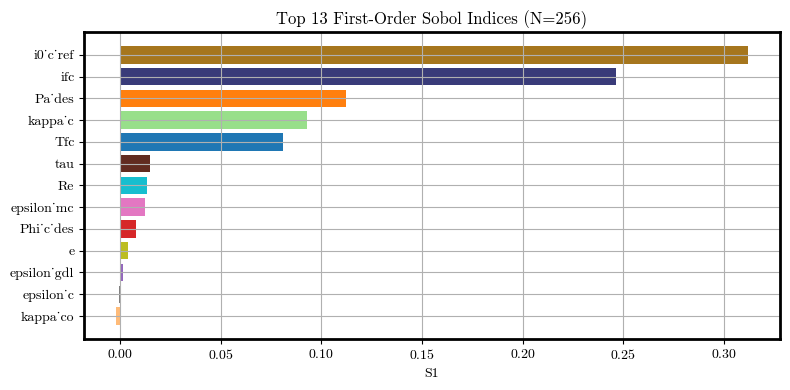

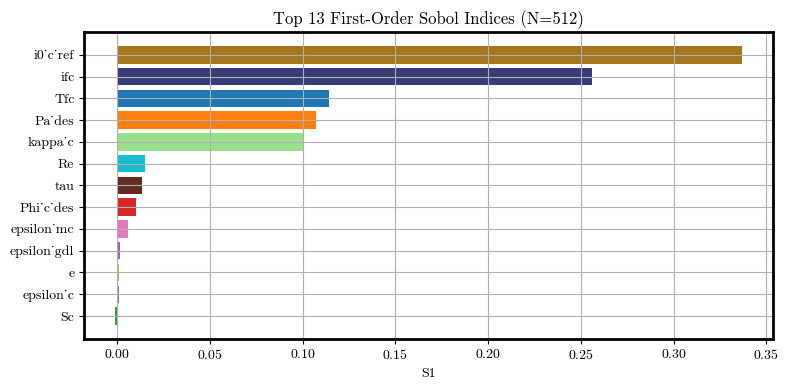

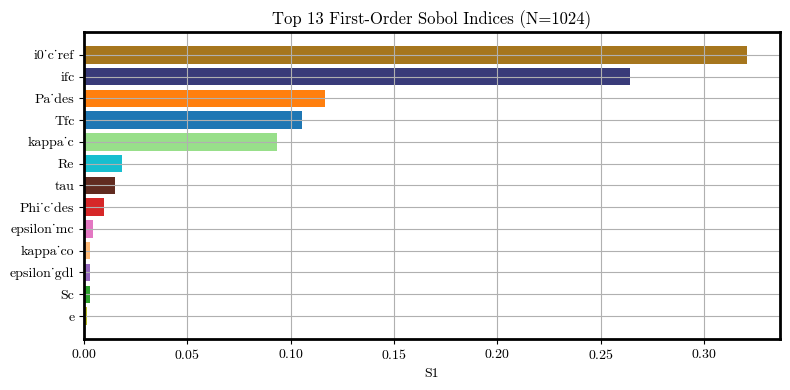

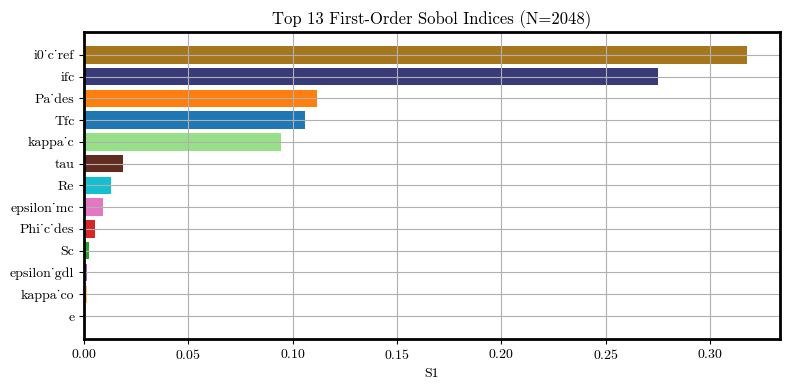

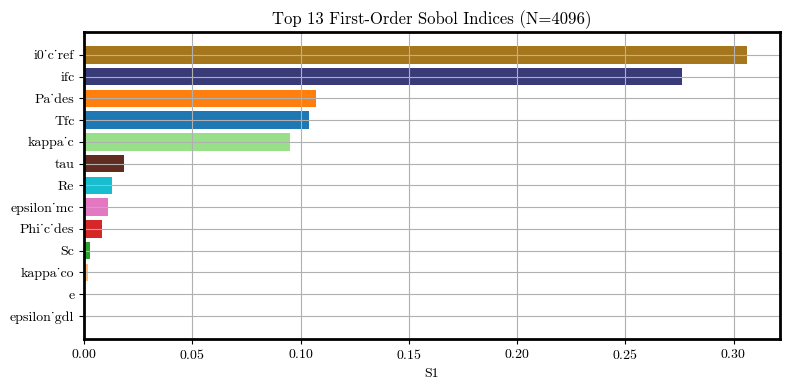

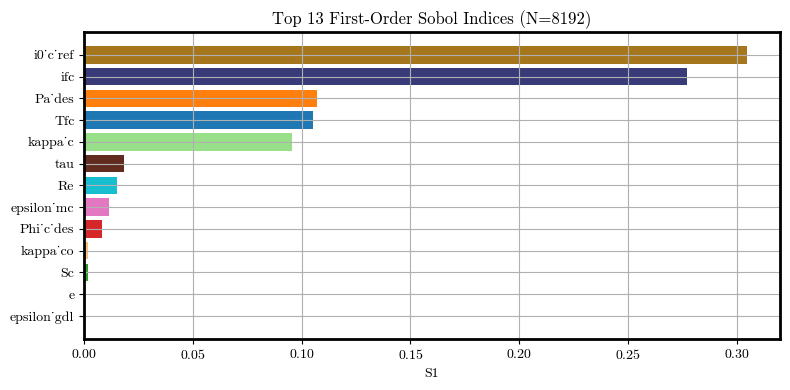

In [17]:
plot_sobol_ranking(FE_ohm_sobol_, top_n=13)

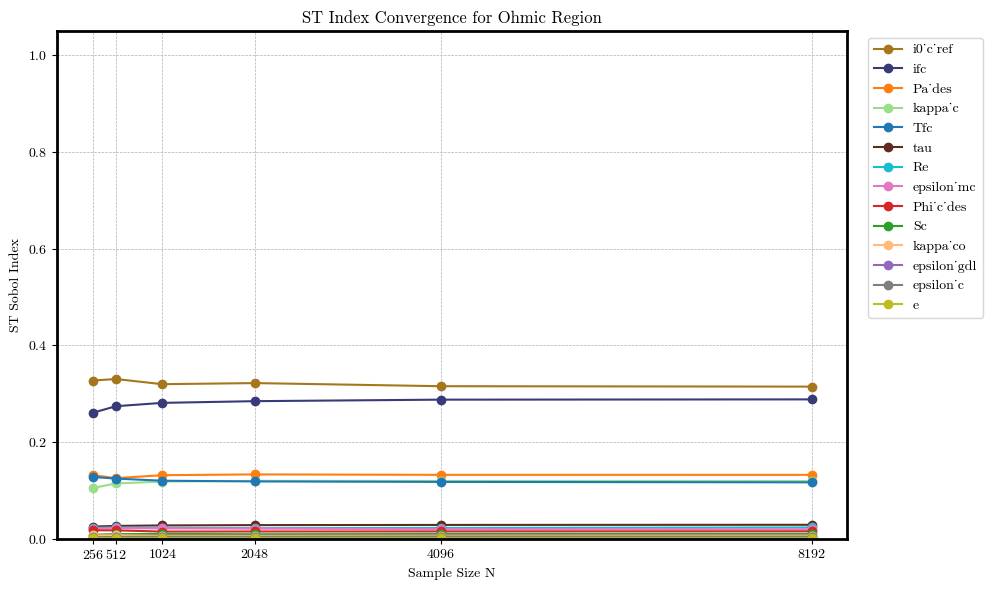

In [18]:
plot_sobol_index_convergence(FE_ohm_sobol_, top_k=14, index_type="ST", log_x=False, region = "Ohmic")

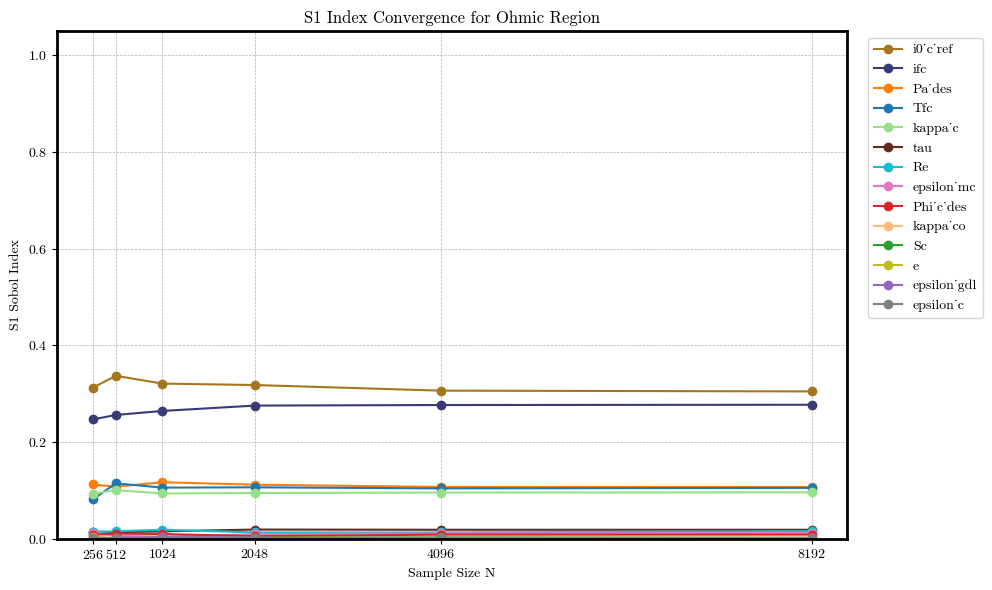

In [19]:
plot_sobol_index_convergence(FE_ohm_sobol_, top_k=14, index_type="S1", log_x=False, region = "Ohmic")

In [20]:
save_FE_results(
    region_name="ohmic",
    raw_shap =RAW_shap_values_ohm,
    shap_df =FE_ohm_shap_results,
    sobol_results=FE_ohm_sobol_,
    save_dir="../results/sm/xgboost",
    tag="28072025"
)

[INFO] Saved SHAP ranking to ../results/sm/xgboost\xgb_ohmic_28072025_shap.csv
[INFO] Saved raw SHAP Explanation to ../results/sm/xgboost\xgb_ohmic_28072025_raw_shap.pkl
[INFO] Saved all Sobol results to ../results/sm/xgboost\xgb_ohmic_28072025_sobol_results.pkl


## **Mass transport**

In [ ]:
# Optionally, load the results
#FE_mass_shap_results, FE_mass_sobol_ = load_FE_results(region_name = "mass_transport", 
#                save_dir = "../results/sm/xgboost", 
#                tag="17072025")

[INFO] Loaded SHAP ranking from ../results/sm/xgboost\xgb_mass_transport_17072025_shap.csv
[INFO] Loaded Sobol results from ../results/sm/xgboost\xgb_mass_transport_17072025_sobol_results.pkl


In [42]:
FE_mass = FeatureEffects(model=model_xgboost, parameter_ranges =parameter_ranges, region="mass_transport")

In [22]:
RAW_shap_values_mass, FE_mass_shap_results = FE_mass.shap(df= df_exploded, target_col='Ucell', sample_frac=1.0, verbose=True)

[WARN] Found non-numeric columns: ['ifc']
[INFO] Converted column 'ifc' to numeric.
[INFO] Using full dataset (817523 rows) for SHAP.
[INFO] Creating SHAP TreeExplainer...
[INFO] Computing SHAP values...
[INFO] columns ['Tfc', 'Pa_des', 'Sc', 'Phi_c_des', 'epsilon_gdl', 'tau', 'epsilon_mc', 'epsilon_c', 'e', 'Re', 'i0_c_ref', 'kappa_co', 'kappa_c', 'ifc']
[INFO] Aggregating mean absolute SHAP values per feature...


In [23]:
FE_mass_shap_results

,feature,mean_abs_shap
13,ifc,0.114768
10,i0_c_ref,0.042725
1,Pa_des,0.034335
0,Tfc,0.032391
9,Re,0.021942
12,kappa_c,0.021652
5,tau,0.017343
6,epsilon_mc,0.014117
3,Phi_c_des,0.007848
2,Sc,0.007055


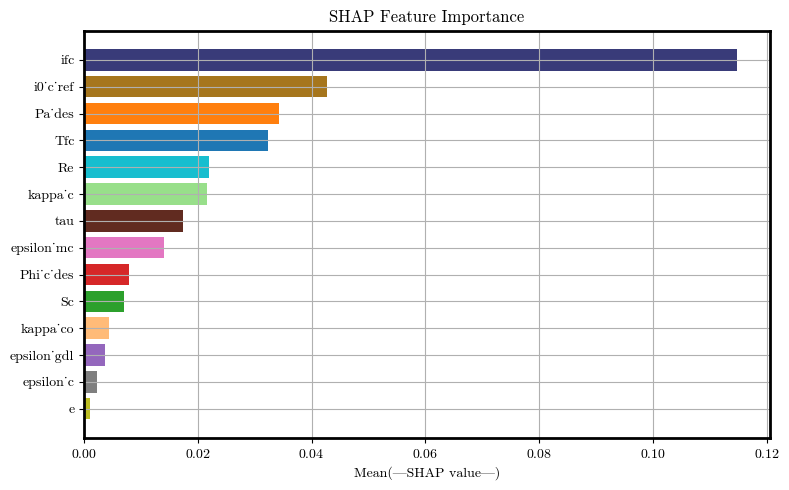

In [40]:
plot_shap_bar(FE_mass_shap_results,top_n=14)

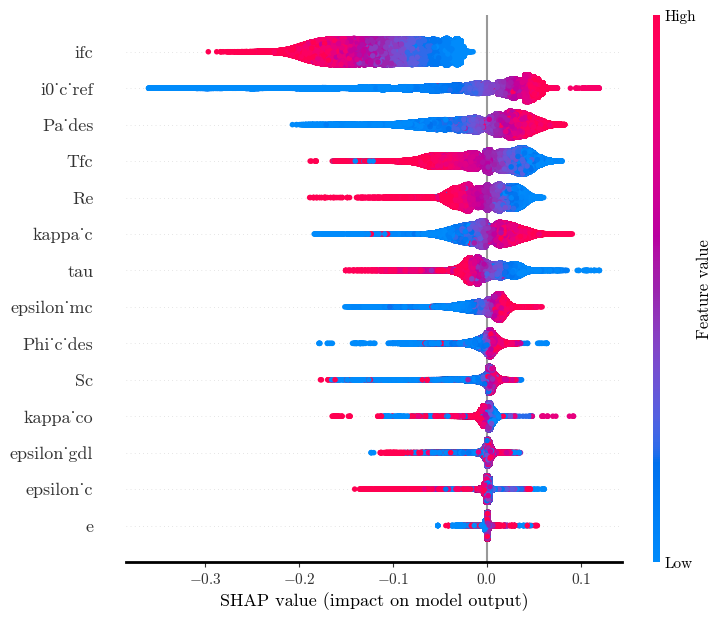

In [25]:
shap.plots.beeswarm(RAW_shap_values_mass, max_display=14)

In [43]:
N_list = [256, 512, 1024, 2048, 4096, 8192]  
FE_mass_sobol_ = FE_mass.sobol(N_list= N_list, calculate_second_order=True,verbose=True)

d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 256 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.8684
[INFO] Sum S2 (unique pairs) = 0.6499
[INFO] Sum S1 + S2 = 1.5183 (should be ≈ 1)
[INFO] Sum ST = 1.1020 (may be > 1 due to overlaps)
[WARNING] S1 + S2 does not sum to 1 — surrogate may be biased or incomplete.


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 512 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9526
[INFO] Sum S2 (unique pairs) = 0.0894
[INFO] Sum S1 + S2 = 1.0419 (should be ≈ 1)
[INFO] Sum ST = 1.1507 (may be > 1 due to overlaps)


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


...

[INFO] Analyzing 2048 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9335
[INFO] Sum S2 (unique pairs) = 0.0573
[INFO] Sum S1 + S2 = 0.9908 (should be ≈ 1)
[INFO] Sum ST = 1.1084 (may be > 1 due to overlaps)


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 4096 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9098
[INFO] Sum S2 (unique pairs) = 0.0755
[INFO] Sum S1 + S2 = 0.9854 (should be ≈ 1)
[INFO] Sum ST = 1.1059 (may be > 1 due to overlaps)


d:\Users\kju10\Documents\LMU-STATISTICS & DATA SCIENCE MASTER\WS2425\Consulting\project\Sensitivity-Analysis-and-Surrogate-Modeling-of-PEM-Fuel-Cells\.venv\Lib\site-packages\SALib\util\__init__.py:274: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  names = list(pd.unique(groups))


[INFO] Analyzing 8192 samples...
[INFO] S1
[INFO] Calculating second-order Sobol indices...
[INFO] final df data
[INFO] Sum S1 = 0.9217
[INFO] Sum S2 (unique pairs) = 0.0510
[INFO] Sum S1 + S2 = 0.9727 (should be ≈ 1)
[INFO] Sum ST = 1.1068 (may be > 1 due to overlaps)


In [39]:
FE_mass_sobol_[8192]['sobol_df']

,feature,S1,S1_CI,ST,ST_CI,S2_total,S2_CI
0,i0_c_ref,0.273354,"(0.255, 0.291)",0.285164,"(0.272, 0.299)",0.004424,"(-0.08, 0.089)"
1,ifc,0.172609,"(0.161, 0.185)",0.186311,"(0.179, 0.194)",0.000000,"(0.0, 0.0)"
2,Pa_des,0.152373,"(0.14, 0.165)",0.185339,"(0.178, 0.193)",0.038121,"(-0.203, 0.28)"
3,Tfc,0.128192,"(0.118, 0.139)",0.148554,"(0.142, 0.155)",-0.014818,"(-0.232, 0.203)"
4,Re,0.069569,"(0.06, 0.079)",0.083003,"(0.08, 0.086)",0.004475,"(-0.05, 0.059)"
5,kappa_c,0.036081,"(0.028, 0.044)",0.060771,"(0.058, 0.063)",0.002259,"(-0.009, 0.013)"
6,tau,0.042606,"(0.036, 0.049)",0.055016,"(0.052, 0.058)",0.006850,"(-0.066, 0.08)"
7,epsilon_mc,0.029046,"(0.022, 0.036)",0.039519,"(0.038, 0.041)",-0.011413,"(-0.076, 0.053)"
8,Phi_c_des,0.010420,"(0.006, 0.015)",0.023469,"(0.021, 0.025)",-0.008079,"(-0.076, 0.06)"
9,Sc,0.004694,"(0.001, 0.009)",0.018997,"(0.018, 0.02)",0.017602,"(-0.046, 0.082)"


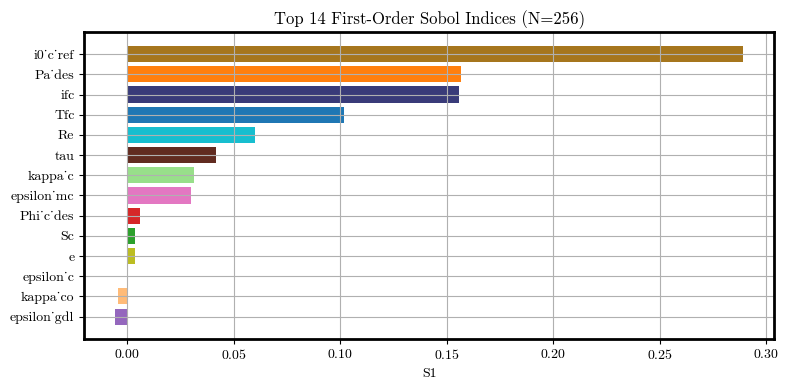

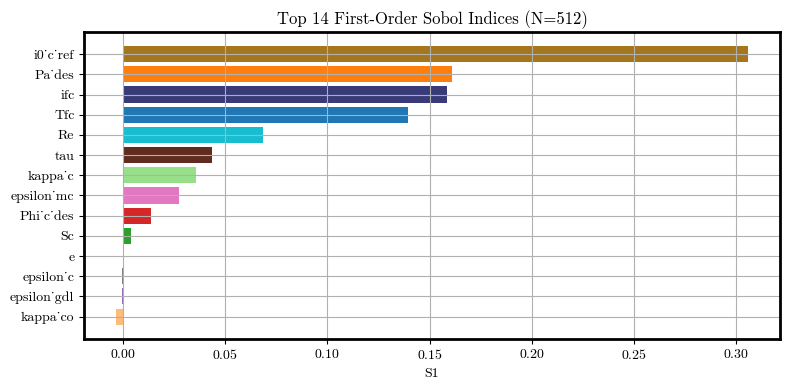

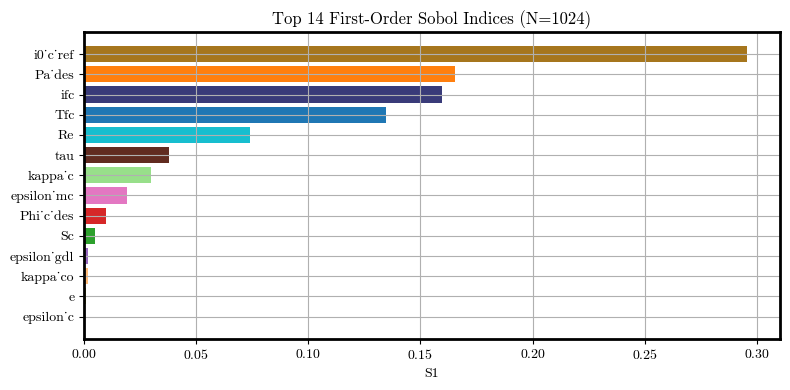

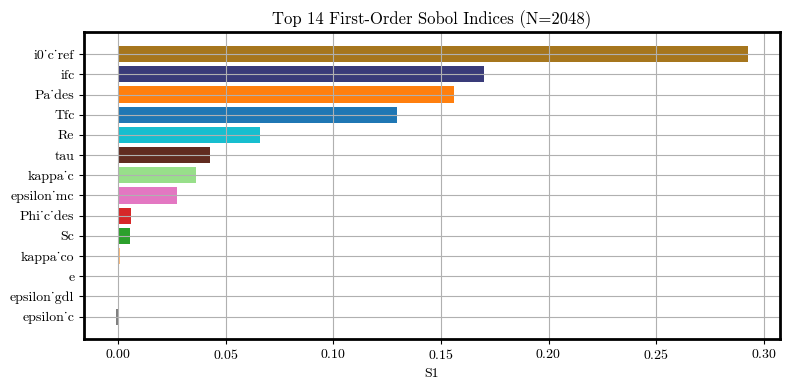

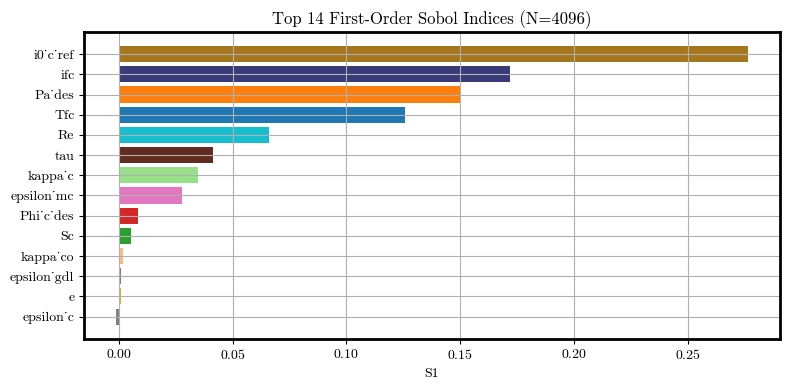

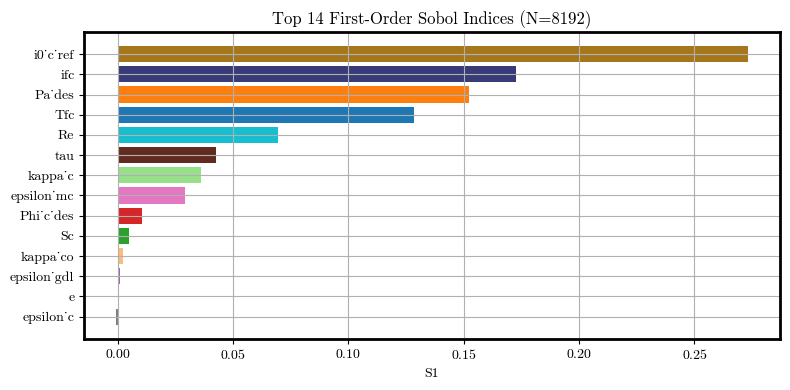

In [27]:
plot_sobol_ranking(FE_mass_sobol_, top_n=14)

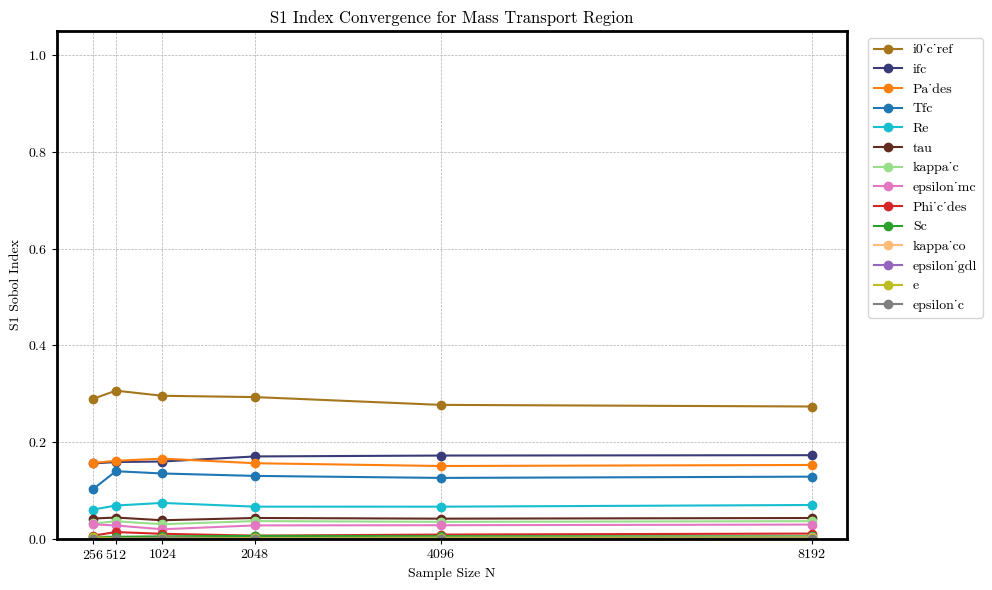

In [ ]:
plot_sobol_index_convergence(FE_mass_sobol_, top_k=14, index_type="ST", log_x=False, region = "Mass Transport")

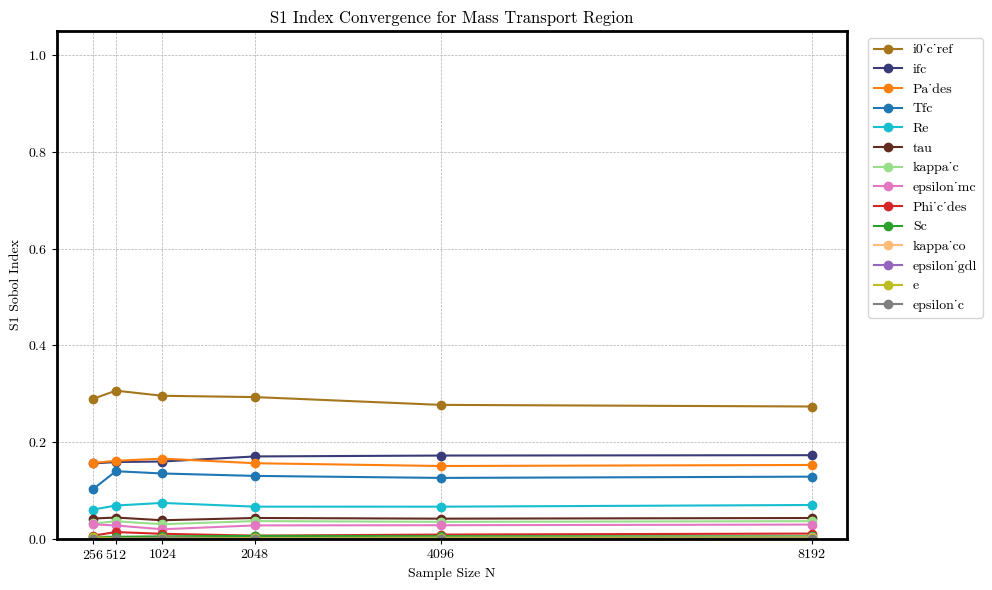

In [31]:
plot_sobol_index_convergence(FE_mass_sobol_, top_k=14, index_type="S1", log_x=False, region = "Mass Transport")

In [32]:
save_FE_results(
    region_name="mass_transport",
    raw_shap =RAW_shap_values_mass,
    shap_df =FE_mass_shap_results,
    sobol_results=FE_mass_sobol_,
    save_dir="../results/sm/xgboost",
    tag="28072025"
)

[INFO] Saved SHAP ranking to ../results/sm/xgboost\xgb_mass_transport_28072025_shap.csv
[INFO] Saved raw SHAP Explanation to ../results/sm/xgboost\xgb_mass_transport_28072025_raw_shap.pkl
[INFO] Saved all Sobol results to ../results/sm/xgboost\xgb_mass_transport_28072025_sobol_results.pkl


## Read the files to get the summary

In [26]:
FE_act_shap_results, RAW_shap_values_act ,FE_act_sobol_ = load_FE_results(
    region_name="activation",
    save_dir="../results/sm/xgboost",
    tag="28072025"
)


FE_ohm_shap_results, RAW_shap_values_ohm,FE_ohm_sobol_ = load_FE_results(
    region_name="ohmic",
    save_dir="../results/sm/xgboost",
    tag="28072025"
)


FE_mass_shap_results, RAW_shap_values_mass,FE_mass_sobol_ = load_FE_results(
    region_name="mass_transport",
    save_dir="../results/sm/xgboost",
    tag="28072025"
)

[INFO] Loaded SHAP ranking from ../results/sm/xgboost\xgb_activation_28072025_shap.csv
[INFO] Loaded raw SHAP Explanation from ../results/sm/xgboost\xgb_activation_28072025_raw_shap.pkl
[INFO] Loaded Sobol results from ../results/sm/xgboost\xgb_activation_28072025_sobol_results.pkl
[INFO] Loaded SHAP ranking from ../results/sm/xgboost\xgb_ohmic_28072025_shap.csv
[INFO] Loaded raw SHAP Explanation from ../results/sm/xgboost\xgb_ohmic_28072025_raw_shap.pkl
[INFO] Loaded Sobol results from ../results/sm/xgboost\xgb_ohmic_28072025_sobol_results.pkl
[INFO] Loaded SHAP ranking from ../results/sm/xgboost\xgb_mass_transport_28072025_shap.csv
[INFO] Loaded raw SHAP Explanation from ../results/sm/xgboost\xgb_mass_transport_28072025_raw_shap.pkl
[INFO] Loaded Sobol results from ../results/sm/xgboost\xgb_mass_transport_28072025_sobol_results.pkl


In [ ]:
df_sobol_S1 = pd.DataFrame(
    list(zip(
        FE_mass_sobol_[8192]['Si']['param'],
        FE_mass_sobol_[8192]['Si']['S1'],
        FE_mass_sobol_[8192]['Si']['S1_conf'],
        FE_mass_sobol_[8192]['Si']['ST'],
        FE_mass_sobol_[8192]['Si']['ST_conf']
    )),
    columns=['param', 'S1', 'S1_conf','ST', 'ST_conf']
)
df_sobol_S1

,param,S1,S1_conf,ST,ST_conf
0,Tfc,0.124973,0.011375,0.148972,0.006142
1,Pa_des,0.148188,0.012088,0.181104,0.007326
2,Sc,0.005447,0.004384,0.020444,0.001428
3,Phi_c_des,0.009428,0.004495,0.023353,0.001867
4,epsilon_gdl,0.001858,0.003165,0.010131,0.000778
5,tau,0.044123,0.007562,0.060464,0.002914
6,epsilon_mc,0.029365,0.006550,0.042467,0.002021
7,epsilon_c,-0.000780,0.002394,0.005598,0.000679
8,e,0.000657,0.000974,0.000852,0.000076
9,Re,0.072117,0.009009,0.084935,0.002981


In [ ]:
FE_mass_sobol_[8192]['sobol_df']

,feature,S1,S1_CI,ST,ST_CI,S2_total,S2_CI
0,i0_c_ref,0.266349,"(0.249, 0.284)",0.278743,"(0.265, 0.292)",-0.002374,"(-0.085, 0.08)"
1,ifc,0.177646,"(0.165, 0.19)",0.190026,"(0.182, 0.198)",0.000000,"(0.0, 0.0)"
2,Pa_des,0.148188,"(0.136, 0.16)",0.181104,"(0.174, 0.188)",0.013770,"(-0.228, 0.255)"
3,Tfc,0.124973,"(0.114, 0.136)",0.148972,"(0.143, 0.155)",0.011396,"(-0.209, 0.232)"
4,Re,0.072117,"(0.063, 0.081)",0.084935,"(0.082, 0.088)",-0.009561,"(-0.065, 0.046)"
5,kappa_c,0.035114,"(0.027, 0.043)",0.061085,"(0.058, 0.064)",0.001853,"(-0.01, 0.013)"
6,tau,0.044123,"(0.037, 0.052)",0.060464,"(0.058, 0.063)",0.038646,"(-0.041, 0.118)"
7,epsilon_mc,0.029365,"(0.023, 0.036)",0.042467,"(0.04, 0.044)",-0.016639,"(-0.078, 0.044)"
8,Phi_c_des,0.009428,"(0.005, 0.014)",0.023353,"(0.021, 0.025)",0.000943,"(-0.068, 0.07)"
9,Sc,0.005447,"(0.001, 0.01)",0.020444,"(0.019, 0.022)",0.012547,"(-0.057, 0.082)"


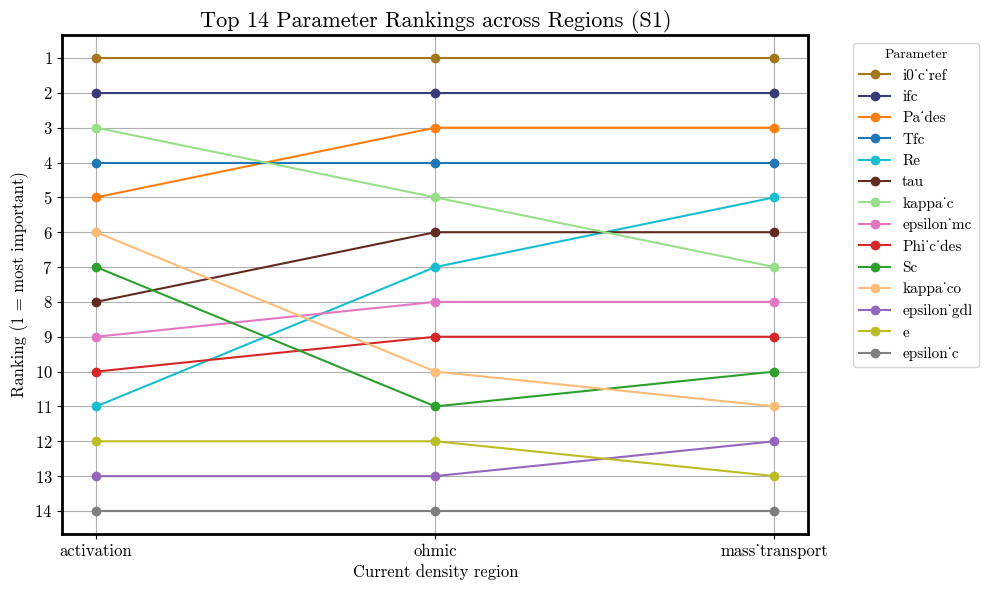

In [81]:
plot_top_k_rankings_across_regions(
    rank_sources={
        "activation": FE_act_sobol_[8192]["sobol_df"],
        "ohmic": FE_ohm_sobol_[8192]["sobol_df"],
        "mass_transport": FE_mass_sobol_[8192]["sobol_df"]
    },
    source_type="S1",
    top_k=14
)

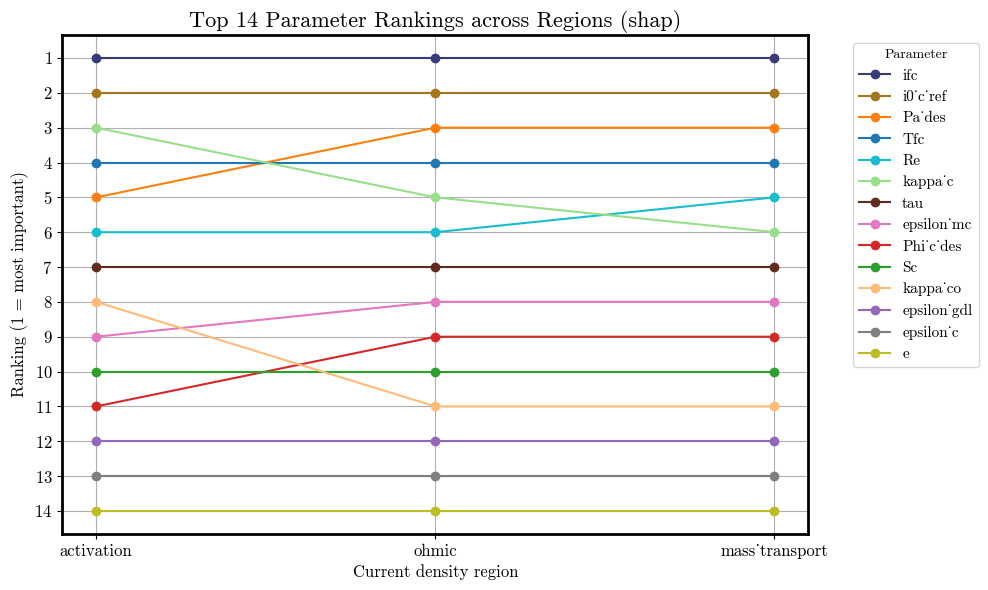

In [82]:
plot_top_k_rankings_across_regions(
    rank_sources={
        "activation": FE_act_shap_results,
        "ohmic": FE_ohm_shap_results,
        "mass_transport": FE_mass_shap_results
    },
    source_type="shap",
    top_k=14
)

In [53]:
FE_act_sobol_[8192]

{'sobol_df':         feature        S1            S1_CI        ST           ST_CI  \
 0      i0_c_ref  0.434374    (0.41, 0.459)  0.442186  (0.425, 0.459)   
 1       kappa_c  0.183423   (0.169, 0.198)  0.210842  (0.202, 0.219)   
 2           ifc  0.186998   (0.175, 0.199)  0.193935  (0.186, 0.202)   
 3           Tfc  0.076767   (0.068, 0.086)  0.081779  (0.079, 0.085)   
 4        Pa_des  0.046647   (0.038, 0.055)  0.073890   (0.07, 0.078)   
 5      kappa_co  0.009841   (0.006, 0.014)  0.018324  (0.017, 0.019)   
 6            Sc  0.005716   (0.003, 0.009)  0.013566  (0.013, 0.014)   
 7           tau  0.003993   (0.001, 0.007)  0.009477   (0.009, 0.01)   
 8    epsilon_mc  0.003200   (0.001, 0.006)  0.007103  (0.007, 0.007)   
 9            Re  0.001707  (-0.001, 0.004)  0.005565  (0.005, 0.006)   
 10    Phi_c_des  0.002405   (0.001, 0.004)  0.004630  (0.004, 0.005)   
 11  epsilon_gdl -0.000330  (-0.002, 0.001)  0.002606  (0.002, 0.003)   
 12    epsilon_c -0.000529  (-0.002, 0.

In [91]:
selected_features_per_region_sobol, union_set_sobol =select_top_features(
    rank_sources={
        "activation": FE_act_sobol_[8192]["sobol_df"],
        "ohmic": FE_ohm_sobol_[8192]["sobol_df"],
        "mass_transport": FE_mass_sobol_[8192]["sobol_df"]
    },
    source_type="S1",
    method="threshold",
    threshold=0.9,top_k=None
)


Region: activation
Selected 5 features using method='threshold' (threshold=0.9)
Total importance explained: 0.928
Selected features: ['i0_c_ref', 'ifc', 'kappa_c', 'Tfc', 'Pa_des']

Region: ohmic
Selected 6 features using method='threshold' (threshold=0.9)
Total importance explained: 0.908
Selected features: ['i0_c_ref', 'ifc', 'Pa_des', 'Tfc', 'kappa_c', 'tau']

Region: mass_transport
Selected 8 features using method='threshold' (threshold=0.9)
Total importance explained: 0.904
Selected features: ['i0_c_ref', 'ifc', 'Pa_des', 'Tfc', 'Re', 'tau', 'kappa_c', 'epsilon_mc']

Union of all selected features across regions: ['Pa_des', 'Re', 'Tfc', 'epsilon_mc', 'i0_c_ref', 'ifc', 'kappa_c', 'tau']
Total unique features selected: 8


In [74]:
build_rank_table(selected_features_per_region_sobol)

,activation,ohmic,mass_transport
i0_c_ref,1,1,1
ifc,2,2,2
kappa_c,3,5,<NA>
Tfc,4,4,4
Pa_des,<NA>,3,3
Re,<NA>,<NA>,5
tau,<NA>,<NA>,6


In [70]:
selected_features_per_region_sobol

{'activation': ['i0_c_ref', 'ifc', 'kappa_c', 'Tfc'],
 'ohmic': ['i0_c_ref', 'ifc', 'Pa_des', 'Tfc', 'kappa_c'],
 'mass_transport': ['i0_c_ref', 'ifc', 'Pa_des', 'Tfc', 'Re', 'tau']}

In [92]:
selected_features_per_region_shap, union_set_shap = select_top_features(
    rank_sources={
        "activation": FE_act_shap_results,
        "ohmic": FE_ohm_shap_results,
        "mass_transport": FE_mass_shap_results
    },
    source_type="shap",
    method="topk",
    top_k=5
)


Region: activation
Selected 5 features using method='topk' (top_k=5)
Total importance explained: 0.878
Selected features: ['ifc', 'i0_c_ref', 'kappa_c', 'Tfc', 'Pa_des']

Region: ohmic
Selected 5 features using method='topk' (top_k=5)
Total importance explained: 0.762
Selected features: ['ifc', 'i0_c_ref', 'Pa_des', 'Tfc', 'kappa_c']

Region: mass_transport
Selected 5 features using method='topk' (top_k=5)
Total importance explained: 0.756
Selected features: ['ifc', 'i0_c_ref', 'Pa_des', 'Tfc', 'Re']

Union of all selected features across regions: ['Pa_des', 'Re', 'Tfc', 'i0_c_ref', 'ifc', 'kappa_c']
Total unique features selected: 6


In [75]:
build_rank_table(selected_features_per_region_shap)

,activation,ohmic,mass_transport
ifc,1,1,1
i0_c_ref,2,2,2
kappa_c,3,5,<NA>
Tfc,4,4,4
Pa_des,5,3,3
Re,<NA>,<NA>,5


In [94]:
common, additional = compare_selected_features(dict_a = selected_features_per_region_shap, dict_b = selected_features_per_region_sobol, name_a="SHAP", name_b="Sobol")
print("Common features (intersection):", common)
print("Additional features:", additional)

Common features (intersection): ['Pa_des', 'Re', 'Tfc', 'i0_c_ref', 'ifc', 'kappa_c']
Additional features: {'SHAP': [], 'Sobol': ['epsilon_mc', 'tau']}
